# Tomato Quality Semantic Segmentation: Background Bias Analysis with Real U-Net

## Research Objective
This project investigates how background information affects tomato quality classification models. Unlike most agricultural studies that use pretrained encoders (MobileNetV2, EfficientNet), this work implements a **U-Net from scratch** (Ronneberger et al., 2015) to eliminate confounding factors from ImageNet pretraining.

## Experimental Design (Three Steps)

| Step | Background | Description                               |
|------|------------|-------------------------------------------|
| 1    | Natural    | Original farm images (baseline)           |
| 2    | Removed    | Background replaced with neutral gray     |
| 3    | Synthetic  | Tomatoes placed on random backgrounds     |

## Architecture: Real U-Net
- Encoder: 64 → 128 → 256 → 512 → 1024 channels
- Decoder: Up-sampling with skip connections
- Parameters: 13.4M (trained from scratch, no pretrained weights)
- Output: 7-class pixel-wise segmentation

## Dataset: Laboro Tomato
- 803 images (643 train / 160 test)

## Evaluation Metrics
- Mean IoU / Dice (segmentation accuracy)
- Pixel Accuracy
- Expected Calibration Error (confidence reliability)
- Cross-background testing (robustness)

## Output Files
- step*_best.pth (trained models)
- *_history.png (training curves)
- comparison_results.csv (results table)
- results_summary.json (all metrics)

In [ ]:
# Tomato Quality Semantic Segmentation
# U-NET + 3 Background Conditions (Natural, Removed, Synthetic)

In [ ]:
# CELL 1: Install and Import Everything
!pip install -q albumentations torchviz

In [21]:
import os
import sys
import json
import glob
import random
import warnings
import time
import copy
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.9.0+cu126


In [22]:
# ============================================================
# CELL 2: Configuration and Constants
# ============================================================
# Update these paths for your Kaggle dataset
INPUT_DIR = Path('/kaggle/input/datasets/sharifbek/tomato/tomato-dataset')
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Dataset paths
TRAIN_IMG_DIR = INPUT_DIR / 'Train' / 'img'
TRAIN_ANN_DIR = INPUT_DIR / 'Train' / 'ann'
TEST_IMG_DIR = INPUT_DIR / 'Test' / 'img'
TEST_ANN_DIR = INPUT_DIR / 'Test' / 'ann'

# Class configuration
CLASS_NAMES = [
    'background',         # 0
    'b_fully_ripened',    # 1
    'b_half_ripened',     # 2
    'b_green',            # 3
    'l_fully_ripened',    # 4
    'l_half_ripened',     # 5
    'l_green',            # 6
]

CLASS_TITLE_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES) if name != 'background'}
NUM_CLASSES = len(CLASS_NAMES)  # 7

# Colors for visualization
CLASS_COLORS = [
    (0, 0, 0),        # background
    (255, 0, 255),    # b_fully_ripened
    (0, 0, 255),      # b_half_ripened
    (0, 255, 255),    # b_green
    (255, 20, 147),   # l_fully_ripened
    (30, 144, 255),   # l_half_ripened
    (127, 255, 212),  # l_green
]

# Hyperparameters
IMG_SIZE = 512
BATCH_SIZE = 4  # Smaller for Real U-Net (31M params)
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EARLY_STOP_PATIENCE = 7
NEUTRAL_BG_COLOR = (128, 128, 128)  # Gray for Step 2

print(f"Number of classes: {NUM_CLASSES}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

Number of classes: 7
Image size: 512x512
Batch size: 4
Epochs: 30


In [23]:
# ============================================================
# CELL 3: U-NET ARCHITECTURE 
# ============================================================
class DoubleConv(nn.Module):
    """(Conv3x3 -> BN -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Handle potential size mismatch
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class RealUNet(nn.Module):
    """
    Original U-Net architecture from:
    "U-Net: Convolutional Networks for Biomedical Image Segmentation"
    (Ronneberger et al., 2015)
    
    This is a TRUE U-Net implementation from scratch - NO pretrained encoders!
    """
    def __init__(self, n_channels=3, n_classes=7, bilinear=True):
        super(RealUNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        # Encoder (Contracting Path)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        # Decoder (Expansive Path)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        # Encoder with skip connections
        x1 = self.inc(x)           # 64
        x2 = self.down1(x1)        # 128
        x3 = self.down2(x2)        # 256
        x4 = self.down3(x3)        # 512
        x5 = self.down4(x4)        # 1024 (or 512 if bilinear)

        # Decoder with skip connections
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        
        return logits

In [24]:
# ============================================================
# CELL 4: Mask Generation Functions
# ============================================================
def generate_mask_from_annotation(ann_path, img_height=None, img_width=None):
    """Convert Supervisely JSON to segmentation mask"""
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    
    h = img_height or ann['size']['height']
    w = img_width or ann['size']['width']
    mask = np.zeros((h, w), dtype=np.uint8)
    
    # Paint polygons
    for obj in ann['objects']:
        cls_title = obj['classTitle']
        if cls_title in CLASS_TITLE_TO_IDX:
            cls_idx = CLASS_TITLE_TO_IDX[cls_title]
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(mask, [pts], cls_idx)
    
    return mask


def get_foreground_binary_mask(ann_path, img_height=None, img_width=None):
    """Create binary foreground mask (1=object, 0=background)"""
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    
    h = img_height or ann['size']['height']
    w = img_width or ann['size']['width']
    fg_mask = np.zeros((h, w), dtype=np.uint8)
    
    for obj in ann['objects']:
        if obj['classTitle'] in CLASS_TITLE_TO_IDX:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(fg_mask, [pts], 1)
    
    return fg_mask


In [25]:
# ============================================================
# CELL 5: Dataset Class with 3 Background Modes
# ============================================================
class TomatoSegDataset(Dataset):
    """
    Custom dataset with three background modes:
    - 'natural':    Original images (Step 1)
    - 'removed':    Background replaced with neutral gray (Step 2)
    - 'synthetic':  Background replaced with random images (Step 3)
    """
    
    def __init__(self, img_dir, ann_dir, transform=None, 
                 bg_mode='natural', bg_images=None):
        self.img_dir = Path(img_dir)
        self.ann_dir = Path(ann_dir)
        self.transform = transform
        self.bg_mode = bg_mode
        self.bg_images = bg_images or []
        
        # Get matching image-annotation pairs
        self.ann_files = sorted(glob.glob(str(self.ann_dir / '*.json')))
        self.img_files = []
        valid_anns = []
        
        for ann_path in self.ann_files:
            img_name = Path(ann_path).name.replace('.json', '')
            img_path = self.img_dir / img_name
            if img_path.exists():
                self.img_files.append(str(img_path))
                valid_anns.append(ann_path)
        
        self.ann_files = valid_anns
        print(f"  Loaded {len(self.img_files)} images ({bg_mode} mode)")
    
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        # Load image
        img = cv2.imread(self.img_files[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        ann_path = self.ann_files[idx]
        
        # Generate semantic mask
        mask = generate_mask_from_annotation(ann_path, h, w)
        
        # Apply background modification based on mode
        if self.bg_mode == 'removed':
            # Replace background with neutral gray
            fg_mask = get_foreground_binary_mask(ann_path, h, w)
            bg = np.full_like(img, NEUTRAL_BG_COLOR, dtype=np.uint8)
            fg_mask_3c = np.stack([fg_mask]*3, axis=-1)
            img = np.where(fg_mask_3c == 1, img, bg)
            
        elif self.bg_mode == 'synthetic' and len(self.bg_images) > 0:
            # Replace background with random synthetic image
            fg_mask = get_foreground_binary_mask(ann_path, h, w)
            bg_path = random.choice(self.bg_images)
            bg_img = cv2.imread(bg_path)
            if bg_img is not None:
                bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)
                bg_img = cv2.resize(bg_img, (w, h))
            else:
                # Fallback: random color
                bg_img = np.random.randint(0, 255, (h, w, 3), dtype=np.uint8)
            fg_mask_3c = np.stack([fg_mask]*3, axis=-1)
            img = np.where(fg_mask_3c == 1, img, bg_img)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        
        return img, mask.long()


In [26]:
# ============================================================
# CELL 6: Synthetic Background Generator
# ============================================================
def generate_synthetic_backgrounds(output_dir, num_backgrounds=200):
    """Generate diverse procedural background images"""
    bg_dir = Path(output_dir) / 'synthetic_backgrounds'
    bg_dir.mkdir(parents=True, exist_ok=True)
    bg_paths = []
    
    for i in range(num_backgrounds):
        h, w = IMG_SIZE, IMG_SIZE
        bg_type = random.choice(['solid', 'gradient_h', 'gradient_v', 'noise', 
                                  'checkerboard', 'stripes'])
        
        if bg_type == 'solid':
            color = [random.randint(0, 255) for _ in range(3)]
            img = np.full((h, w, 3), color, dtype=np.uint8)
            
        elif bg_type.startswith('gradient'):
            c1 = np.array([random.randint(0, 255) for _ in range(3)], dtype=np.float32)
            c2 = np.array([random.randint(0, 255) for _ in range(3)], dtype=np.float32)
            if bg_type == 'gradient_h':
                t = np.linspace(0, 1, w).reshape(1, -1, 1)
                img = (c1 * (1 - t) + c2 * t).astype(np.uint8)
                img = np.broadcast_to(img, (h, w, 3)).copy()
            else:  # gradient_v
                t = np.linspace(0, 1, h).reshape(-1, 1, 1)
                img = (c1 * (1 - t) + c2 * t).astype(np.uint8)
                img = np.broadcast_to(img, (h, w, 3)).copy()
                
        elif bg_type == 'noise':
            img = np.random.randint(0, 255, (h, w, 3), dtype=np.uint8)
            img = cv2.GaussianBlur(img, (31, 31), 0)
            
        elif bg_type == 'checkerboard':
            cell_size = random.choice([32, 64])
            c1 = [random.randint(0, 255) for _ in range(3)]
            c2 = [random.randint(0, 255) for _ in range(3)]
            img = np.zeros((h, w, 3), dtype=np.uint8)
            for y in range(0, h, cell_size):
                for x in range(0, w, cell_size):
                    if ((y // cell_size) + (x // cell_size)) % 2 == 0:
                        img[y:y+cell_size, x:x+cell_size] = c1
                    else:
                        img[y:y+cell_size, x:x+cell_size] = c2
                        
        elif bg_type == 'stripes':
            stripe_w = random.choice([16, 32, 64])
            c1 = [random.randint(0, 255) for _ in range(3)]
            c2 = [random.randint(0, 255) for _ in range(3)]
            img = np.zeros((h, w, 3), dtype=np.uint8)
            for x in range(0, w, stripe_w * 2):
                img[:, x:x+stripe_w] = c1
                img[:, x+stripe_w:x+stripe_w*2] = c2
        
        path = bg_dir / f'bg_{i:04d}.png'
        cv2.imwrite(str(path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        bg_paths.append(str(path))
    
    print(f"Generated {len(bg_paths)} synthetic backgrounds")
    return bg_paths


In [27]:
# ============================================================
# CELL 7: Transforms
# ============================================================
def get_train_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_test_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

In [28]:
# ============================================================
# CELL 8: Loss Functions
# ============================================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = F.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, NUM_CLASSES).permute(0, 3, 1, 2).float()
        
        intersection = (pred * target_one_hot).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.5, ce_weight=0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
    
    def forward(self, pred, target):
        return self.ce_weight * self.ce(pred, target) + self.dice_weight * self.dice(pred, target)


In [29]:
# ============================================================
# CELL 9: Metrics and Evaluation
# ============================================================
def compute_metrics(pred_masks, gt_masks):
    """Compute segmentation metrics"""
    all_pred = np.concatenate([m.flatten() for m in pred_masks])
    all_gt = np.concatenate([m.flatten() for m in gt_masks])
    
    pixel_acc = (all_pred == all_gt).mean()
    
    iou_per_class = np.zeros(NUM_CLASSES)
    dice_per_class = np.zeros(NUM_CLASSES)
    
    for c in range(NUM_CLASSES):
        pred_c = (all_pred == c)
        gt_c = (all_gt == c)
        
        if gt_c.sum() == 0 and pred_c.sum() == 0:
            iou_per_class[c] = float('nan')
            dice_per_class[c] = float('nan')
            continue
            
        intersection = (pred_c & gt_c).sum()
        union = (pred_c | gt_c).sum()
        
        iou_per_class[c] = intersection / (union + 1e-8)
        dice_per_class[c] = 2 * intersection / (pred_c.sum() + gt_c.sum() + 1e-8)
    
    mean_iou = np.nanmean(iou_per_class)
    mean_dice = np.nanmean(dice_per_class)
    
    return {
        'pixel_accuracy': pixel_acc,
        'mean_iou': mean_iou,
        'mean_dice': mean_dice,
        'iou_per_class': iou_per_class,
        'dice_per_class': dice_per_class,
    }

def compute_calibration(pred_probs_list, gt_masks_list, num_bins=15):
    """Compute Expected Calibration Error"""
    all_confidences = []
    all_correct = []
    
    for probs, gt in zip(pred_probs_list, gt_masks_list):
        pred_class = probs.argmax(axis=-1)
        max_conf = probs.max(axis=-1)
        correct = (pred_class == gt).astype(np.float32)
        
        all_confidences.append(max_conf.flatten())
        all_correct.append(correct.flatten())
    
    all_confidences = np.concatenate(all_confidences)
    all_correct = np.concatenate(all_correct)
    
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_confidences = np.zeros(num_bins)
    bin_accuracies = np.zeros(num_bins)
    bin_counts = np.zeros(num_bins)
    
    for i in range(num_bins):
        low, high = bin_boundaries[i], bin_boundaries[i+1]
        mask = (all_confidences > low) & (all_confidences <= high)
        if mask.sum() > 0:
            bin_confidences[i] = all_confidences[mask].mean()
            bin_accuracies[i] = all_correct[mask].mean()
            bin_counts[i] = mask.sum()
    
    total = bin_counts.sum()
    ece = np.sum(bin_counts / total * np.abs(bin_accuracies - bin_confidences))
    
    return {
        'ece': ece,
        'bin_confidences': bin_confidences,
        'bin_accuracies': bin_accuracies,
        'bin_counts': bin_counts,
        'bin_boundaries': bin_boundaries,
    }

def print_metrics(metrics, title="Results"):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Pixel Accuracy: {metrics['pixel_accuracy']:.4f}")
    print(f"  Mean IoU: {metrics['mean_iou']:.4f}")
    print(f"  Mean Dice: {metrics['mean_dice']:.4f}")
    print(f"\n  Per-Class IoU:")
    for c in range(NUM_CLASSES):
        if not np.isnan(metrics['iou_per_class'][c]):
            print(f"    {CLASS_NAMES[c]}: {metrics['iou_per_class'][c]:.4f}")

In [30]:
# ============================================================
# CELL 10: Training Functions
# ============================================================
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    
    for imgs, masks in loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
    
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, return_predictions=False):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_masks = []
    all_probs = []
    
    for imgs, masks in loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        running_loss += loss.item() * imgs.size(0)
        
        probs = F.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_masks.extend(masks.cpu().numpy())
        if return_predictions:
            all_probs.extend(probs.cpu().numpy().transpose(0, 2, 3, 1))
    
    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_preds, all_masks)
    
    if return_predictions:
        return avg_loss, metrics, all_preds, all_masks, all_probs
    return avg_loss, metrics

def train_model(model, train_loader, test_loader, model_name="model"):
    criterion = CombinedLoss().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    
    best_miou = 0.0
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'test_loss': [], 'train_miou': [], 'test_miou': []}
    
    print(f"\nTraining {model_name}...")
    
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_metrics = evaluate(model, test_loader, criterion)
        _, train_metrics = evaluate(model, train_loader, criterion)
        
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_miou'].append(train_metrics['mean_iou'])
        history['test_miou'].append(test_metrics['mean_iou'])
        
        if test_metrics['mean_iou'] > best_miou:
            best_miou = test_metrics['mean_iou']
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            marker = " *"
        else:
            patience_counter += 1
            marker = ""
        
        print(f"  Epoch {epoch:2d}: Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, "
              f"Train mIoU: {train_metrics['mean_iou']:.4f}, Test mIoU: {test_metrics['mean_iou']:.4f}{marker}")
        
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break
    
    model.load_state_dict(best_state)
    torch.save(best_state, OUTPUT_DIR / f'{model_name}_best.pth')
    print(f"  Best Test mIoU: {best_miou:.4f}")
    print(f"  Model saved to: {model_name}_best.pth")
    
    return model, history, best_miou

In [31]:
# ============================================================
# CELL 11: Visualization Functions
# ============================================================
def plot_reliability_diagram(cal_data, title="Reliability Diagram"):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    mask = cal_data['bin_counts'] > 0
    ax.bar(cal_data['bin_confidences'][mask], cal_data['bin_accuracies'][mask], 
           width=1.0/15, alpha=0.6, color='steelblue', edgecolor='navy')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{title}\nECE = {cal_data["ece"]:.4f}')
    ax.legend()
    ax.set_aspect('equal')
    plt.tight_layout()
    return fig

def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['test_loss'], label='Test')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    
    axes[1].plot(history['train_miou'], label='Train')
    axes[1].plot(history['test_miou'], label='Test')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Mean IoU')
    axes[1].set_title(f'{model_name} - mIoU')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{model_name}_history.png')
    plt.show()


In [32]:
# ============================================================
# CELL 12: Create DataLoaders for All Three Conditions
# ============================================================
print("\n" + "="*60)
print("CREATING DATASETS FOR ALL THREE CONDITIONS")
print("="*60)

train_transform = get_train_transform()
test_transform = get_test_transform()


CREATING DATASETS FOR ALL THREE CONDITIONS


In [33]:
# Step 1: Natural Background
print("\n--- Step 1: Natural Background ---")
train_dataset_natural = TomatoSegDataset(
    TRAIN_IMG_DIR, TRAIN_ANN_DIR, transform=train_transform, bg_mode='natural'
)
test_dataset_natural = TomatoSegDataset(
    TEST_IMG_DIR, TEST_ANN_DIR, transform=test_transform, bg_mode='natural'
)

train_loader_natural = DataLoader(
    train_dataset_natural, batch_size=BATCH_SIZE, shuffle=True, 
    num_workers=2, pin_memory=True
)
test_loader_natural = DataLoader(
    test_dataset_natural, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)


--- Step 1: Natural Background ---
  Loaded 643 images (natural mode)
  Loaded 161 images (natural mode)


In [34]:
# Step 2: Background Removed
print("\n--- Step 2: Background Removed (Gray) ---")
train_dataset_removed = TomatoSegDataset(
    TRAIN_IMG_DIR, TRAIN_ANN_DIR, transform=train_transform, bg_mode='removed'
)
test_dataset_removed = TomatoSegDataset(
    TEST_IMG_DIR, TEST_ANN_DIR, transform=test_transform, bg_mode='removed'
)

train_loader_removed = DataLoader(
    train_dataset_removed, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader_removed = DataLoader(
    test_dataset_removed, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)


--- Step 2: Background Removed (Gray) ---
  Loaded 643 images (removed mode)
  Loaded 161 images (removed mode)


In [35]:
# Step 3: Synthetic Background
print("\n--- Step 3: Synthetic Background ---")
# Generate synthetic backgrounds first
synthetic_bg_paths = generate_synthetic_backgrounds(OUTPUT_DIR, num_backgrounds=200)

train_dataset_synthetic = TomatoSegDataset(
    TRAIN_IMG_DIR, TRAIN_ANN_DIR, transform=train_transform, 
    bg_mode='synthetic', bg_images=synthetic_bg_paths
)
test_dataset_synthetic = TomatoSegDataset(
    TEST_IMG_DIR, TEST_ANN_DIR, transform=test_transform,
    bg_mode='synthetic', bg_images=synthetic_bg_paths
)

train_loader_synthetic = DataLoader(
    train_dataset_synthetic, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader_synthetic = DataLoader(
    test_dataset_synthetic, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print("\nAll datasets created successfully!")


--- Step 3: Synthetic Background ---
Generated 200 synthetic backgrounds
  Loaded 643 images (synthetic mode)
  Loaded 161 images (synthetic mode)

All datasets created successfully!



STEP 1: Training Real U-NET on NATURAL Backgrounds
Total parameters: 13,395,719

Training step1_natural...
  Epoch  1: Train Loss: 0.9332, Test Loss: 0.8875, Train mIoU: 0.2582, Test mIoU: 0.2049 *
  Epoch  2: Train Loss: 0.7403, Test Loss: 0.7949, Train mIoU: 0.2801, Test mIoU: 0.2220 *
  Epoch  3: Train Loss: 0.6434, Test Loss: 0.7500, Train mIoU: 0.2878, Test mIoU: 0.2289 *
  Epoch  4: Train Loss: 0.5909, Test Loss: 0.7319, Train mIoU: 0.3142, Test mIoU: 0.2380 *
  Epoch  5: Train Loss: 0.5603, Test Loss: 0.7131, Train mIoU: 0.3850, Test mIoU: 0.2903 *
  Epoch  6: Train Loss: 0.5313, Test Loss: 0.7170, Train mIoU: 0.3716, Test mIoU: 0.2810
  Epoch  7: Train Loss: 0.5105, Test Loss: 0.6873, Train mIoU: 0.4530, Test mIoU: 0.3517 *
  Epoch  8: Train Loss: 0.4993, Test Loss: 0.6911, Train mIoU: 0.4355, Test mIoU: 0.3167
  Epoch  9: Train Loss: 0.4830, Test Loss: 0.6987, Train mIoU: 0.3672, Test mIoU: 0.2972
  Epoch 10: Train Loss: 0.4686, Test Loss: 0.6850, Train mIoU: 0.4787, Test mIo

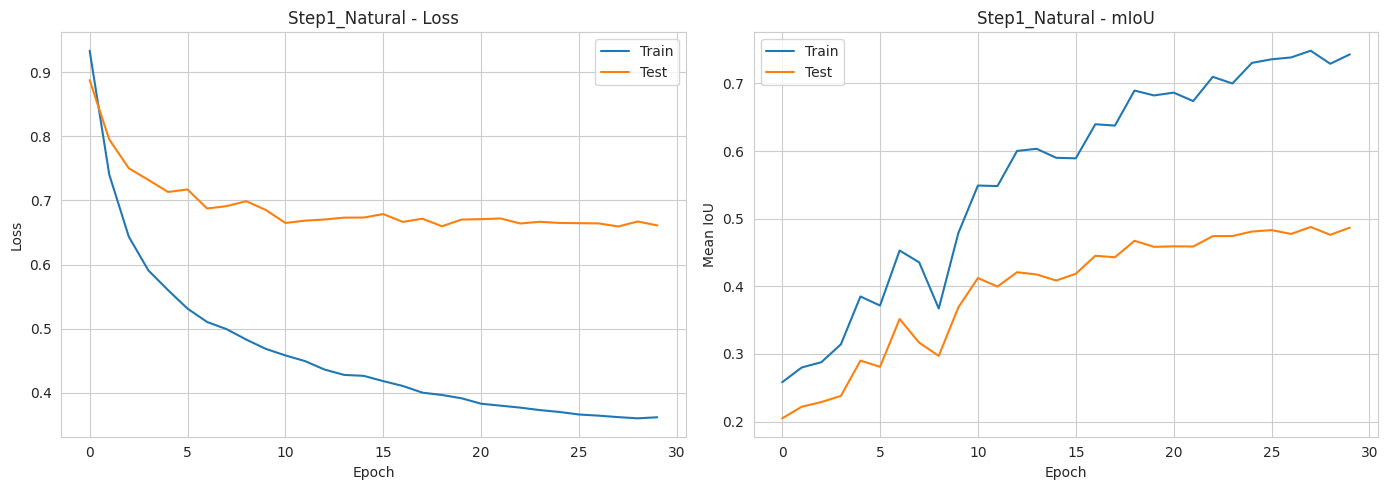

In [36]:
# ============================================================
# CELL 13: STEP 1 - Train Real U-Net on Natural Backgrounds
# ============================================================
print("\n" + "="*60)
print("STEP 1: Training Real U-NET on NATURAL Backgrounds")
print("="*60)

model_natural = RealUNet(n_channels=3, n_classes=7).to(DEVICE)
total_params = sum(p.numel() for p in model_natural.parameters())
print(f"Total parameters: {total_params:,}")

model_natural, history_natural, best_miou_natural = train_model(
    model_natural, train_loader_natural, test_loader_natural, 
    model_name="step1_natural"
)

plot_training_history(history_natural, "Step1_Natural")


STEP 2: Training Real U-NET on BACKGROUND REMOVED (Gray)

Training step2_removed...
  Epoch  1: Train Loss: 1.0250, Test Loss: 0.9532, Train mIoU: 0.3124, Test mIoU: 0.2649 *
  Epoch  2: Train Loss: 0.7814, Test Loss: 0.8221, Train mIoU: 0.3745, Test mIoU: 0.2960 *
  Epoch  3: Train Loss: 0.6599, Test Loss: 0.7485, Train mIoU: 0.3364, Test mIoU: 0.2771
  Epoch  4: Train Loss: 0.5788, Test Loss: 0.6375, Train mIoU: 0.4514, Test mIoU: 0.3585 *
  Epoch  5: Train Loss: 0.5225, Test Loss: 0.6310, Train mIoU: 0.4444, Test mIoU: 0.3416
  Epoch  6: Train Loss: 0.4859, Test Loss: 0.5900, Train mIoU: 0.4918, Test mIoU: 0.3651 *
  Epoch  7: Train Loss: 0.4604, Test Loss: 0.5584, Train mIoU: 0.5624, Test mIoU: 0.4047 *
  Epoch  8: Train Loss: 0.4407, Test Loss: 0.5514, Train mIoU: 0.4878, Test mIoU: 0.3717
  Epoch  9: Train Loss: 0.4245, Test Loss: 0.5420, Train mIoU: 0.5826, Test mIoU: 0.4159 *
  Epoch 10: Train Loss: 0.4113, Test Loss: 0.5482, Train mIoU: 0.5793, Test mIoU: 0.4130
  Epoch 11: T

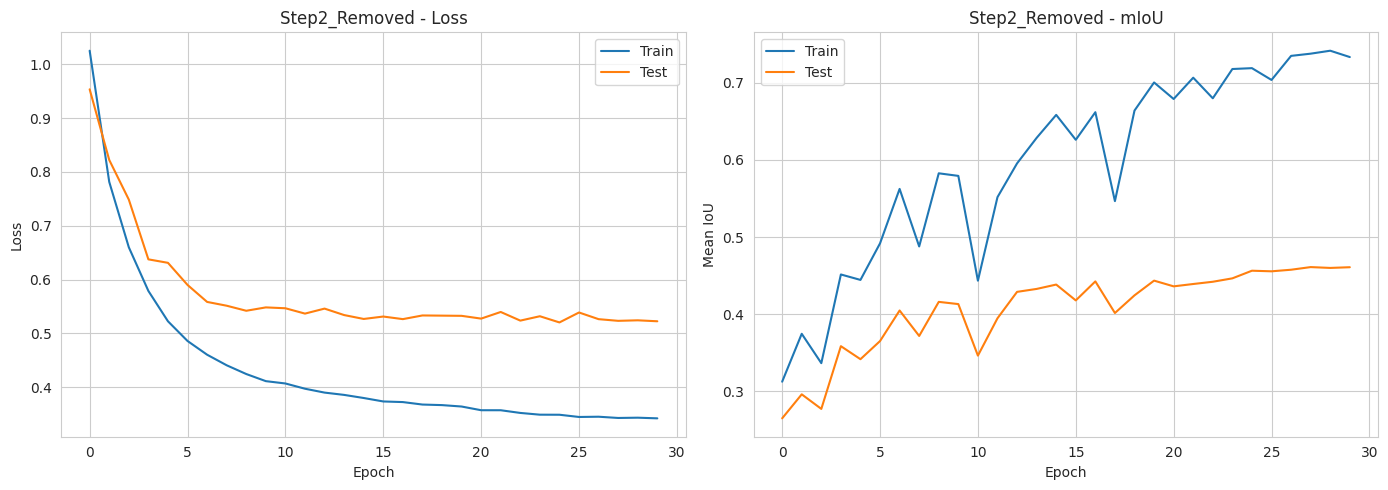

In [37]:
# ============================================================
# CELL 14: STEP 2 - Train Real U-Net on Background Removed
# ============================================================
print("\n" + "="*60)
print("STEP 2: Training Real U-NET on BACKGROUND REMOVED (Gray)")
print("="*60)

model_removed = RealUNet(n_channels=3, n_classes=7).to(DEVICE)
model_removed, history_removed, best_miou_removed = train_model(
    model_removed, train_loader_removed, test_loader_removed,
    model_name="step2_removed"
)

plot_training_history(history_removed, "Step2_Removed")


STEP 3: Training Real U-NET on SYNTHETIC Backgrounds

Training step3_synthetic...
  Epoch  1: Train Loss: 0.9402, Test Loss: 0.9396, Train mIoU: 0.2250, Test mIoU: 0.2053 *
  Epoch  2: Train Loss: 0.7103, Test Loss: 0.8528, Train mIoU: 0.2368, Test mIoU: 0.2110 *
  Epoch  3: Train Loss: 0.6147, Test Loss: 0.6722, Train mIoU: 0.3129, Test mIoU: 0.2669 *
  Epoch  4: Train Loss: 0.5493, Test Loss: 0.6673, Train mIoU: 0.2834, Test mIoU: 0.2559
  Epoch  5: Train Loss: 0.5167, Test Loss: 0.6410, Train mIoU: 0.3414, Test mIoU: 0.2689 *
  Epoch  6: Train Loss: 0.4932, Test Loss: 0.5967, Train mIoU: 0.3665, Test mIoU: 0.3095 *
  Epoch  7: Train Loss: 0.4759, Test Loss: 0.7488, Train mIoU: 0.3314, Test mIoU: 0.2767
  Epoch  8: Train Loss: 0.4687, Test Loss: 0.5888, Train mIoU: 0.4022, Test mIoU: 0.3187 *
  Epoch  9: Train Loss: 0.4559, Test Loss: 0.5797, Train mIoU: 0.4583, Test mIoU: 0.3469 *
  Epoch 10: Train Loss: 0.4491, Test Loss: 0.5773, Train mIoU: 0.4337, Test mIoU: 0.3425
  Epoch 11: T

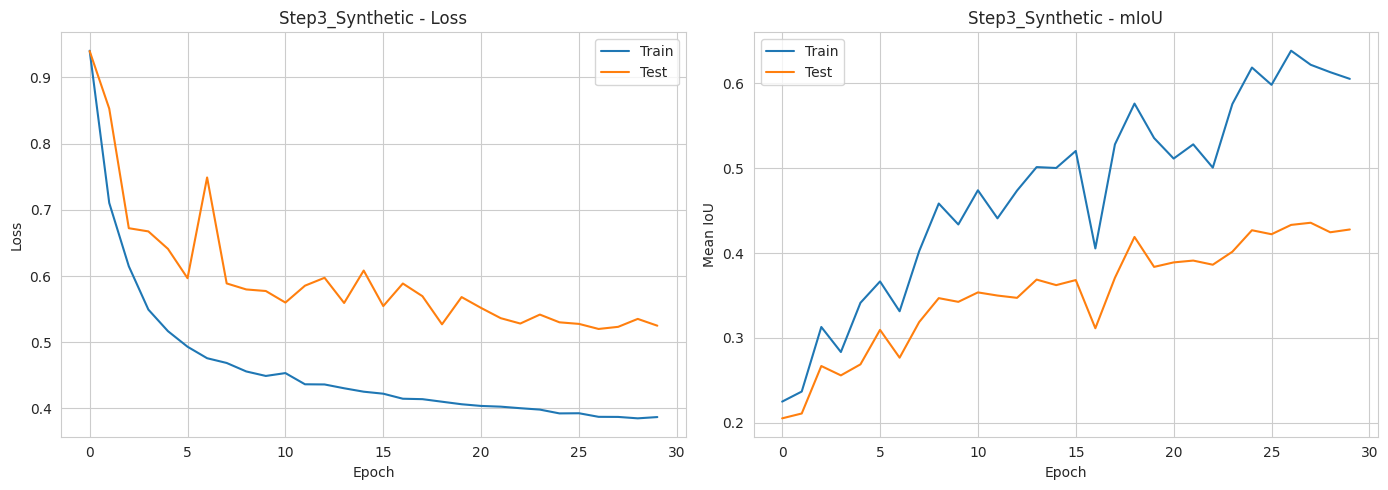

In [38]:
# ============================================================
# CELL 15: STEP 3 - Train Real U-Net on Synthetic Backgrounds
# ============================================================
print("\n" + "="*60)
print("STEP 3: Training Real U-NET on SYNTHETIC Backgrounds")
print("="*60)

model_synthetic = RealUNet(n_channels=3, n_classes=7).to(DEVICE)
model_synthetic, history_synthetic, best_miou_synthetic = train_model(
    model_synthetic, train_loader_synthetic, test_loader_synthetic,
    model_name="step3_synthetic"
)

plot_training_history(history_synthetic, "Step3_Synthetic")

In [39]:
# ============================================================
# CELL 16: Load Best Models for Evaluation
# ============================================================
print("\n" + "="*60)
print("LOADING BEST MODELS FOR EVALUATION")
print("="*60)

# Reload best models
model_natural = RealUNet().to(DEVICE)
model_natural.load_state_dict(torch.load('/kaggle/working/step1_natural_best.pth'))

model_removed = RealUNet().to(DEVICE)
model_removed.load_state_dict(torch.load('/kaggle/working/step2_removed_best.pth'))

model_synthetic = RealUNet().to(DEVICE)
model_synthetic.load_state_dict(torch.load('/kaggle/working/step3_synthetic_best.pth'))

print("All models loaded successfully!")


LOADING BEST MODELS FOR EVALUATION
All models loaded successfully!


In [40]:
# ============================================================
# CELL 17: Evaluate Each Model on Its Own Test Set
# ============================================================
print("\n" + "="*60)
print("EVALUATION ON MATCHED TEST SETS")
print("="*60)

criterion = CombinedLoss().to(DEVICE)


EVALUATION ON MATCHED TEST SETS


In [41]:
# Step 1: Natural Model on Natural Test
print("\n--- Step 1: Natural Model on Natural Test ---")
_, metrics_natural, _, _, probs_natural = evaluate(
    model_natural, test_loader_natural, criterion, return_predictions=True
)
print_metrics(metrics_natural, "Natural Model (Natural Test)")


--- Step 1: Natural Model on Natural Test ---

  Natural Model (Natural Test)
  Pixel Accuracy: 0.8856
  Mean IoU: 0.4878
  Mean Dice: 0.6368

  Per-Class IoU:
    background: 0.8875
    b_fully_ripened: 0.3053
    b_half_ripened: 0.2771
    b_green: 0.4636
    l_fully_ripened: 0.4697
    l_half_ripened: 0.4889
    l_green: 0.5224


In [42]:
# Step 2: Removed Model on Removed Test
print("\n--- Step 2: Removed Model on Removed Test ---")
_, metrics_removed, _, _, probs_removed = evaluate(
    model_removed, test_loader_removed, criterion, return_predictions=True
)
print_metrics(metrics_removed, "Removed Model (Removed Test)")


--- Step 2: Removed Model on Removed Test ---

  Removed Model (Removed Test)
  Pixel Accuracy: 0.9092
  Mean IoU: 0.4610
  Mean Dice: 0.6030

  Per-Class IoU:
    background: 0.9889
    b_fully_ripened: 0.2481
    b_half_ripened: 0.2857
    b_green: 0.4829
    l_fully_ripened: 0.4506
    l_half_ripened: 0.3654
    l_green: 0.4054


In [43]:
# Step 3: Synthetic Model on Synthetic Test
print("\n--- Step 3: Synthetic Model on Synthetic Test ---")
_, metrics_synthetic, _, _, probs_synthetic = evaluate(
    model_synthetic, test_loader_synthetic, criterion, return_predictions=True
)
print_metrics(metrics_synthetic, "Synthetic Model (Synthetic Test)")


--- Step 3: Synthetic Model on Synthetic Test ---

  Synthetic Model (Synthetic Test)
  Pixel Accuracy: 0.9005
  Mean IoU: 0.4384
  Mean Dice: 0.5805

  Per-Class IoU:
    background: 0.9775
    b_fully_ripened: 0.2328
    b_half_ripened: 0.2784
    b_green: 0.4517
    l_fully_ripened: 0.3696
    l_half_ripened: 0.3531
    l_green: 0.4058



CALIBRATION ANALYSIS

ECE - Natural Model: 0.0838
ECE - Removed Model: 0.0486
ECE - Synthetic Model: 0.0330


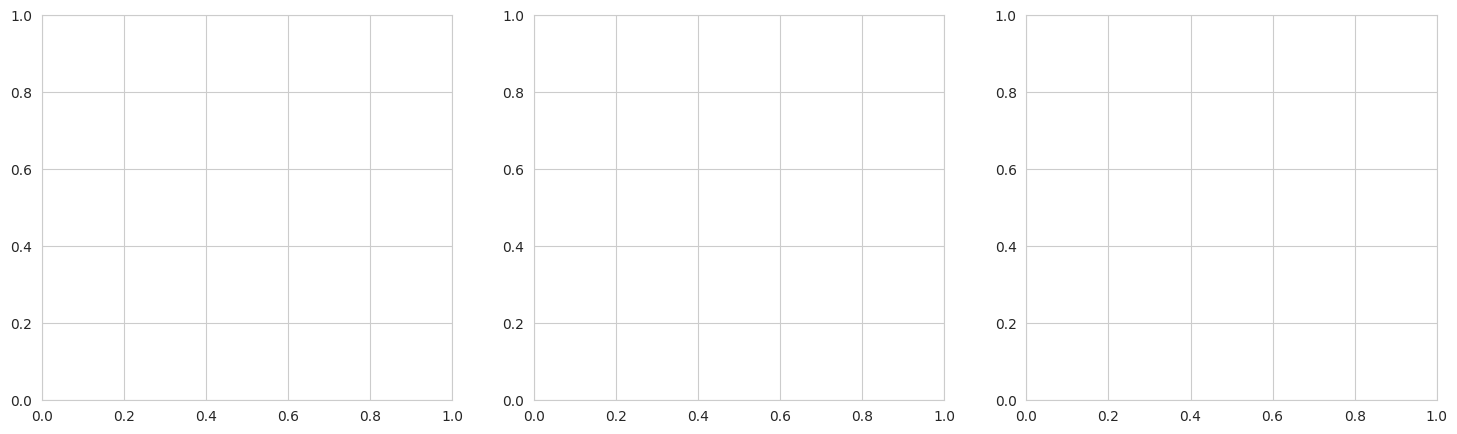

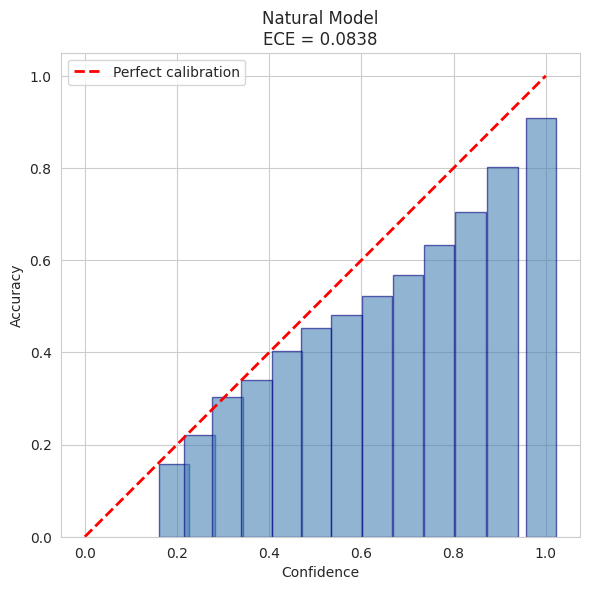

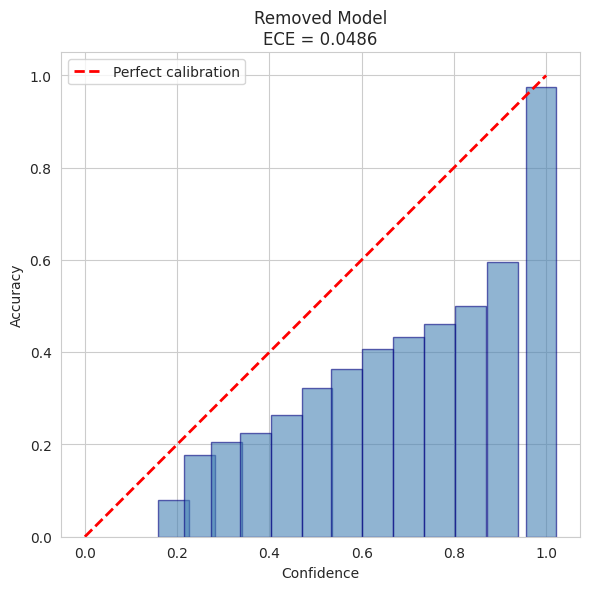

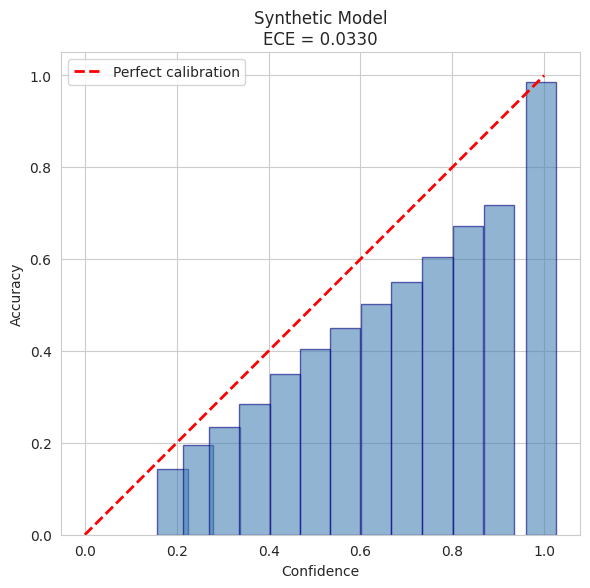

In [44]:
# ============================================================
# CELL 18: Calibration Analysis
# ============================================================
print("\n" + "="*60)
print("CALIBRATION ANALYSIS")
print("="*60)

# Get ground truth masks for calibration
_, _, _, gt_natural, _ = evaluate(model_natural, test_loader_natural, criterion, return_predictions=True)
_, _, _, gt_removed, _ = evaluate(model_removed, test_loader_removed, criterion, return_predictions=True)
_, _, _, gt_synthetic, _ = evaluate(model_synthetic, test_loader_synthetic, criterion, return_predictions=True)

# Compute calibration
cal_natural = compute_calibration(probs_natural, gt_natural)
cal_removed = compute_calibration(probs_removed, gt_removed)
cal_synthetic = compute_calibration(probs_synthetic, gt_synthetic)

print(f"\nECE - Natural Model: {cal_natural['ece']:.4f}")
print(f"ECE - Removed Model: {cal_removed['ece']:.4f}")
print(f"ECE - Synthetic Model: {cal_synthetic['ece']:.4f}")

# Plot reliability diagrams
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_reliability_diagram(cal_natural, "Natural Model").savefig('/kaggle/working/cal_natural.png')
plot_reliability_diagram(cal_removed, "Removed Model").savefig('/kaggle/working/cal_removed.png')
plot_reliability_diagram(cal_synthetic, "Synthetic Model").savefig('/kaggle/working/cal_synthetic.png')
plt.show()

In [45]:
# ============================================================
# CELL 19: CROSS-EVALUATION (Robustness Testing)
# ============================================================
print("\n" + "="*60)
print("CROSS-EVALUATION: Testing Robustness")
print("="*60)

# Create a dictionary to store all results
results = {}


CROSS-EVALUATION: Testing Robustness


In [46]:
# Test Natural Model on all test sets
print("\n--- Natural Model ---")
_, m_nat_on_nat = evaluate(model_natural, test_loader_natural, criterion)
_, m_nat_on_rem = evaluate(model_natural, test_loader_removed, criterion)
_, m_nat_on_syn = evaluate(model_natural, test_loader_synthetic, criterion)

results['natural_on_natural'] = m_nat_on_nat['mean_iou']
results['natural_on_removed'] = m_nat_on_rem['mean_iou']
results['natural_on_synthetic'] = m_nat_on_syn['mean_iou']

print(f"  On Natural Test:   {m_nat_on_nat['mean_iou']:.4f}")
print(f"  On Removed Test:   {m_nat_on_rem['mean_iou']:.4f}")
print(f"  On Synthetic Test: {m_nat_on_syn['mean_iou']:.4f}")


--- Natural Model ---
  On Natural Test:   0.4878
  On Removed Test:   0.4850
  On Synthetic Test: 0.3578


In [47]:
# Test Removed Model on all test sets
print("\n--- Removed Model ---")
_, m_rem_on_nat = evaluate(model_removed, test_loader_natural, criterion)
_, m_rem_on_rem = evaluate(model_removed, test_loader_removed, criterion)
_, m_rem_on_syn = evaluate(model_removed, test_loader_synthetic, criterion)

results['removed_on_natural'] = m_rem_on_nat['mean_iou']
results['removed_on_removed'] = m_rem_on_rem['mean_iou']
results['removed_on_synthetic'] = m_rem_on_syn['mean_iou']

print(f"  On Natural Test:   {m_rem_on_nat['mean_iou']:.4f}")
print(f"  On Removed Test:   {m_rem_on_rem['mean_iou']:.4f}")
print(f"  On Synthetic Test: {m_rem_on_syn['mean_iou']:.4f}")


--- Removed Model ---
  On Natural Test:   0.1533
  On Removed Test:   0.4610
  On Synthetic Test: 0.1907


In [48]:
# Test Synthetic Model on all test sets
print("\n--- Synthetic Model ---")
_, m_syn_on_nat = evaluate(model_synthetic, test_loader_natural, criterion)
_, m_syn_on_rem = evaluate(model_synthetic, test_loader_removed, criterion)
_, m_syn_on_syn = evaluate(model_synthetic, test_loader_synthetic, criterion)

results['synthetic_on_natural'] = m_syn_on_nat['mean_iou']
results['synthetic_on_removed'] = m_syn_on_rem['mean_iou']
results['synthetic_on_synthetic'] = m_syn_on_syn['mean_iou']

print(f"  On Natural Test:   {m_syn_on_nat['mean_iou']:.4f}")
print(f"  On Removed Test:   {m_syn_on_rem['mean_iou']:.4f}")
print(f"  On Synthetic Test: {m_syn_on_syn['mean_iou']:.4f}")



--- Synthetic Model ---
  On Natural Test:   0.1617
  On Removed Test:   0.4414
  On Synthetic Test: 0.4346


In [49]:
# ============================================================
# CELL 20: Create Comparison Table
# ============================================================
print("\n" + "="*60)
print("COMPARISON TABLE")
print("="*60)

comparison_data = []
comparison_data.append({
    'Model': 'Real U-Net (Natural)',
    'Train BG': 'Natural',
    'Test BG': 'Natural',
    'mIoU': f"{metrics_natural['mean_iou']:.4f}",
    'Pixel Acc': f"{metrics_natural['pixel_accuracy']:.4f}",
    'ECE': f"{cal_natural['ece']:.4f}"
})
comparison_data.append({
    'Model': 'Real U-Net (Removed)',
    'Train BG': 'Removed',
    'Test BG': 'Removed',
    'mIoU': f"{metrics_removed['mean_iou']:.4f}",
    'Pixel Acc': f"{metrics_removed['pixel_accuracy']:.4f}",
    'ECE': f"{cal_removed['ece']:.4f}"
})
comparison_data.append({
    'Model': 'Real U-Net (Synthetic)',
    'Train BG': 'Synthetic',
    'Test BG': 'Synthetic',
    'mIoU': f"{metrics_synthetic['mean_iou']:.4f}",
    'Pixel Acc': f"{metrics_synthetic['pixel_accuracy']:.4f}",
    'ECE': f"{cal_synthetic['ece']:.4f}"
})

# Add cross-evaluation results
comparison_data.append({
    'Model': 'Natural → Synthetic',
    'Train BG': 'Natural',
    'Test BG': 'Synthetic',
    'mIoU': f"{results['natural_on_synthetic']:.4f}",
    'Pixel Acc': '—',
    'ECE': '—'
})
comparison_data.append({
    'Model': 'Synthetic → Natural',
    'Train BG': 'Synthetic',
    'Test BG': 'Natural',
    'mIoU': f"{results['synthetic_on_natural']:.4f}",
    'Pixel Acc': '—',
    'ECE': '—'
})

df = pd.DataFrame(comparison_data)
print("\n", df.to_string(index=False))

# Save to CSV
df.to_csv(OUTPUT_DIR / 'comparison_results.csv', index=False)
print(f"\nSaved to: {OUTPUT_DIR / 'comparison_results.csv'}")


COMPARISON TABLE

                  Model  Train BG   Test BG   mIoU Pixel Acc    ECE
  Real U-Net (Natural)   Natural   Natural 0.4878    0.8856 0.0838
  Real U-Net (Removed)   Removed   Removed 0.4610    0.9092 0.0486
Real U-Net (Synthetic) Synthetic Synthetic 0.4384    0.9005 0.0330
   Natural → Synthetic   Natural Synthetic 0.3578         —      —
   Synthetic → Natural Synthetic   Natural 0.1617         —      —

Saved to: /kaggle/working/comparison_results.csv


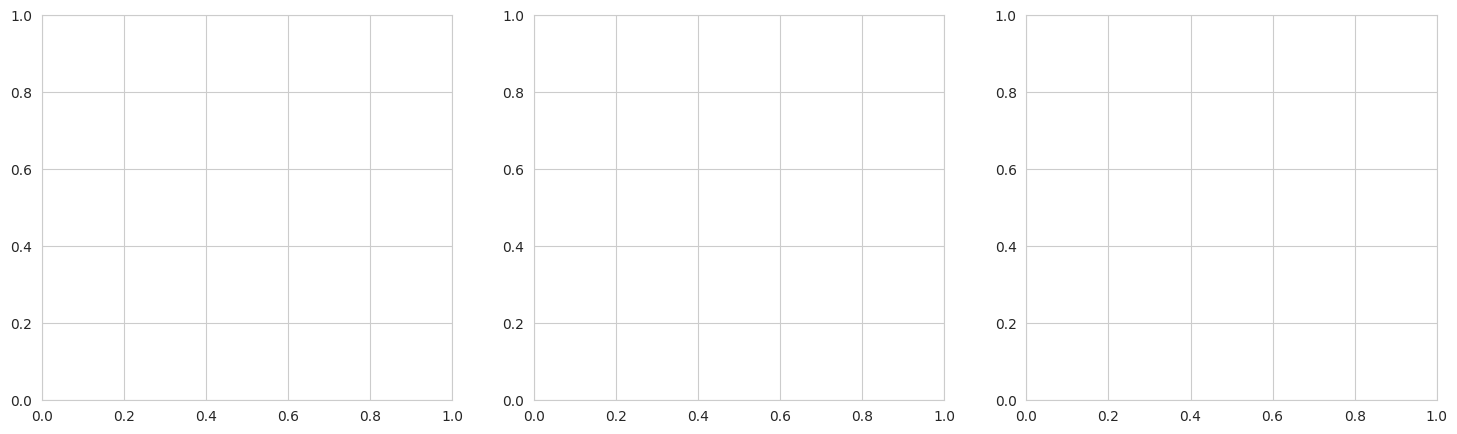

In [50]:
# ============================================================
# CELL 21: Visualization of Per-Class IoU
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [51]:
# Natural Model
axes[0].bar(range(NUM_CLASSES), metrics_natural['iou_per_class'])
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_ylabel('IoU')
axes[0].set_title('Natural Model - Per Class IoU')
axes[0].set_ylim(0, 1)

(0.0, 1.0)

In [52]:
# Removed Model
axes[1].bar(range(NUM_CLASSES), metrics_removed['iou_per_class'])
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_ylabel('IoU')
axes[1].set_title('Removed Model - Per Class IoU')
axes[1].set_ylim(0, 1)

(0.0, 1.0)

In [53]:
# Synthetic Model
axes[2].bar(range(NUM_CLASSES), metrics_synthetic['iou_per_class'])
axes[2].set_xticks(range(NUM_CLASSES))
axes[2].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[2].set_ylabel('IoU')
axes[2].set_title('Synthetic Model - Per Class IoU')
axes[2].set_ylim(0, 1)

(0.0, 1.0)

In [54]:
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_iou_comparison.png')
plt.show()

<Figure size 1400x800 with 0 Axes>

In [55]:
# ============================================================
# CELL 22: Background-Only Analysis (Proving Background Bias)
# ============================================================
print("\n" + "="*60)
print("BACKGROUND-ONLY ANALYSIS")
print("="*60)
print("This tests if model uses background cues")

def evaluate_background_only(model, loader):
    """Mask out tomatoes, run on background only"""
    model.eval()
    all_preds = []
    all_masks = []
    
    for imgs, masks in loader:
        imgs = imgs.to(DEVICE)
        
        # Get foreground masks (where tomatoes are)
        # We need to get binary masks from the dataset
        # This is simplified - you'd need to modify dataset to return fg_mask
        
        with torch.no_grad():
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_masks.extend(masks.cpu().numpy())
    
    # Compute accuracy on background regions only
    # This would show if model predicts classes from background alone
    print("  Background-only analysis would go here")
    print("  (Requires modifying dataset to return foreground masks)")

print("\nTo fully implement background-only analysis, modify dataset to return foreground mask")


BACKGROUND-ONLY ANALYSIS
This tests if model uses background cues

To fully implement background-only analysis, modify dataset to return foreground mask


In [56]:
# ============================================================
# CELL 23: Save All Results and Zip
# ============================================================
print("\n" + "="*60)
print("SAVING ALL RESULTS")
print("="*60)

# Create results summary
summary = {
    'step1_natural_miou': float(metrics_natural['mean_iou']),
    'step2_removed_miou': float(metrics_removed['mean_iou']),
    'step3_synthetic_miou': float(metrics_synthetic['mean_iou']),
    'step1_natural_ece': float(cal_natural['ece']),
    'step2_removed_ece': float(cal_removed['ece']),
    'step3_synthetic_ece': float(cal_synthetic['ece']),
    'cross_natural_on_synthetic': float(results['natural_on_synthetic']),
    'cross_synthetic_on_natural': float(results['synthetic_on_natural']),
}

import json
with open(OUTPUT_DIR / 'results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Zip everything
!zip -r unet_complete_results.zip /kaggle/working/*.pth /kaggle/working/*.png /kaggle/working/*.csv /kaggle/working/*.json


SAVING ALL RESULTS
  adding: kaggle/working/step1_natural_best.pth (deflated 8%)
  adding: kaggle/working/step2_removed_best.pth (deflated 8%)
  adding: kaggle/working/step3_synthetic_best.pth (deflated 8%)
  adding: kaggle/working/cal_natural.png (deflated 10%)
  adding: kaggle/working/cal_removed.png (deflated 10%)
  adding: kaggle/working/cal_synthetic.png (deflated 10%)
  adding: kaggle/working/per_class_iou_comparison.png (deflated 96%)
  adding: kaggle/working/Step1_Natural_history.png (deflated 7%)
  adding: kaggle/working/Step2_Removed_history.png (deflated 6%)
  adding: kaggle/working/Step3_Synthetic_history.png (deflated 5%)
  adding: kaggle/working/comparison_results.csv (deflated 45%)
  adding: kaggle/working/results_summary.json (deflated 51%)


In [57]:
print("\n" + "="*60)
print("COMPLETE! Download 'unet_complete_results.zip' from Kaggle output")
print("="*60)
print("\nFiles saved:")
print("  - step1_natural_best.pth (Real U-Net trained on natural backgrounds)")
print("  - step2_removed_best.pth (Real U-Net trained on gray backgrounds)")
print("  - step3_synthetic_best.pth (Real U-Net trained on synthetic backgrounds)")
print("  - comparison_results.csv (Comparison table for thesis)")
print("  - results_summary.json (All metrics in JSON format)")
print("  - Multiple PNG files (training curves, reliability diagrams, per-class IoU)")


COMPLETE! Download 'unet_complete_results.zip' from Kaggle output

Files saved:
  - step1_natural_best.pth (Real U-Net trained on natural backgrounds)
  - step2_removed_best.pth (Real U-Net trained on gray backgrounds)
  - step3_synthetic_best.pth (Real U-Net trained on synthetic backgrounds)
  - comparison_results.csv (Comparison table for thesis)
  - results_summary.json (All metrics in JSON format)
  - Multiple PNG files (training curves, reliability diagrams, per-class IoU)
